In [1]:
dataset = '1111_SYN_10'

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, roc_curve, auc, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
import cv2
import seaborn as sns

In [3]:
train_dir = str('DS_REAL_SPLITED_' + dataset)

model = YOLO("yolo12n-cls.yaml")

model.train(data=train_dir, epochs=300, imgsz=64, project='YOLO12-RESULTS', name=dataset)

YOLO12n-cls summary: 152 layers, 1,820,976 parameters, 1,820,976 gradients, 3.7 GFLOPs
New https://pypi.org/project/ultralytics/8.3.230 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=DS_REAL_SPLITED_1111_SYN_10, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-cls.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.9±0.1 ms, read: 20.8±2.4 MB/s, size: 35.3 KB)


train: Scanning /tf/2025/SEEDS/DS_REAL_SPLITED_1111_SYN_10/train... 3850 images, 0 corrupt: 100%|██████████| 3850/3850 [


train: New cache created: /tf/2025/SEEDS/DS_REAL_SPLITED_1111_SYN_10/train.cache
val: Fast image access ✅ (ping: 2.7±0.2 ms, read: 8.4±2.6 MB/s, size: 44.5 KB)


...

                   all      0.727      0.985



300 epochs completed in 1.300 hours.
Optimizer stripped from YOLO12-RESULTS/1111_SYN_10/weights/last.pt, 3.7MB
Optimizer stripped from YOLO12-RESULTS/1111_SYN_10/weights/best.pt, 3.7MB

Validating YOLO12-RESULTS/1111_SYN_10/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO12n-cls summary (fused): 94 layers, 1,722,450 parameters, 0 gradients, 3.5 GFLOPs
train: /tf/2025/SEEDS/DS_REAL_SPLITED_1111_SYN_10/train... found 3850 images in 10 classes ✅ 
val: /tf/2025/SEEDS/DS_REAL_SPLITED_1111_SYN_10/val... found 750 images in 10 classes ✅ 
test: /tf/2025/SEEDS/DS_REAL_SPLITED_1111_SYN_10/test... found 750 images in 10 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 24/24 [00:00<00:00, 26.74it/s]


                   all      0.727      0.985
Speed: 0.1ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to YOLO12-RESULTS/1111_SYN_10


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fc5fdf89690>
curves: []
curves_results: []
fitness: 0.8560000061988831
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7266666889190674, 'metrics/accuracy_top5': 0.9853333234786987, 'fitness': 0.8560000061988831}
save_dir: PosixPath('YOLO12-RESULTS/1111_SYN_10')
speed: {'preprocess': 0.06885708666717012, 'inference': 0.3207907013226456, 'loss': 0.00013163066372120133, 'postprocess': 0.00029632535006385297}
task: 'classify'
top1: 0.7266666889190674
top5: 0.9853333234786987

In [4]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report

def avaliar_modelo(model, val_path, imgsz=64, verbose=False):

    val_path = Path(val_path)

    class_names = sorted([d.name for d in val_path.iterdir() if d.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    y_true = []
    y_pred = []

    for cls_name in class_names:
        cls_dir = val_path / cls_name
        label = class_to_idx[cls_name]

        for img_path in cls_dir.glob("*.*"):  # jpg, png, etc.
            try:
                img = Image.open(img_path).convert("RGB")
                results = model.predict(img, imgsz=imgsz, verbose=False)
                pred = int(results[0].probs.top1)

                y_true.append(label)
                y_pred.append(pred)

                if verbose:
                    print(f"Imagem: {img_path.name} | Real: {cls_name} | Previsto: {class_names[pred]}")

            except Exception as e:
                print(f"[ERRO] Falha ao processar {img_path.name}: {e}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    print(f"\n🔍 Acurácia: {acc:.4f}")
    print(report)

    return y_true, y_pred, report

In [5]:
# Carregue seu modelo (pré-treinado ou treinado)
model = YOLO(str('YOLO12-RESULTS/' + dataset + '/weights/best.pt'))

# Caminho para pasta de validação
val_path = str('DS_REAL_SPLITED_' + dataset + '/test')

# Avaliação
y_true, y_pred, relatorio = avaliar_modelo(model, val_path, imgsz=64, verbose=False)



🔍 Acurácia: 0.7747
                   precision    recall  f1-score   support

      BULKCARRIER       0.68      0.57      0.62        75
    CONTAINERSHIP       0.86      0.84      0.85        75
     GENERALCARGO       0.64      0.72      0.68        75
OILPRODUCTSTANKER       0.52      0.32      0.40        75
   PASSENGERSSHIP       0.91      0.89      0.90        75
           TANKER       0.53      0.84      0.65        75
          TRAWLER       0.88      0.84      0.86        75
              TUG       0.92      0.87      0.89        75
  VEHICLESCARRIER       0.94      0.91      0.93        75
            YACHT       0.93      0.95      0.94        75

         accuracy                           0.77       750
        macro avg       0.78      0.77      0.77       750
     weighted avg       0.78      0.77      0.77       750



In [6]:
def plotar_metricas(y_true, y_pred):
    """
    Gera os gráficos de Acurácia, Precisão, Recall e a Matriz de Confusão.
    """
    # 1. Acurácia
    accuracy = accuracy_score(y_true, y_pred)

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 3. Precision
    precision = precision_score(y_true, y_pred, average='macro')

    # 4. Recall
    recall = recall_score(y_true, y_pred, average='macro')

    #5. F1-Score
    f1 = f1_score(y_true, y_pred, average='macro')

    # Plot 1: Gráfico de Acurácia, Precisão e Recall
    metrics = [accuracy, precision, recall, f1]
    metrics_names = ['Acurácia', 'Precisão', 'Recall', 'f1_score']

    plt.figure(figsize=(8, 6))
    plt.bar(metrics_names, metrics, color=['blue', 'green', 'orange', 'yellow'])
    plt.title('Acurácia, Precisão, Recall & F1')
    plt.ylim(0, 1)
    plt.ylabel('Valor')
    for i, value in enumerate(metrics):
        plt.text(i, value + 0.02, f'{value:.4f}', ha='center', va='bottom', fontsize=12)
    plt.show()

    # Plot 2: Matriz de Confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=np.arange(1, cm.shape[1] + 1), yticklabels=np.arange(1, cm.shape[0] + 1))
    plt.title('Matriz de Confusão')
    plt.xlabel('Predições')
    plt.ylabel('Verdadeiros')
    plt.show()

    print(f'Acurácia: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Confusion Matrix:\n{cm}')

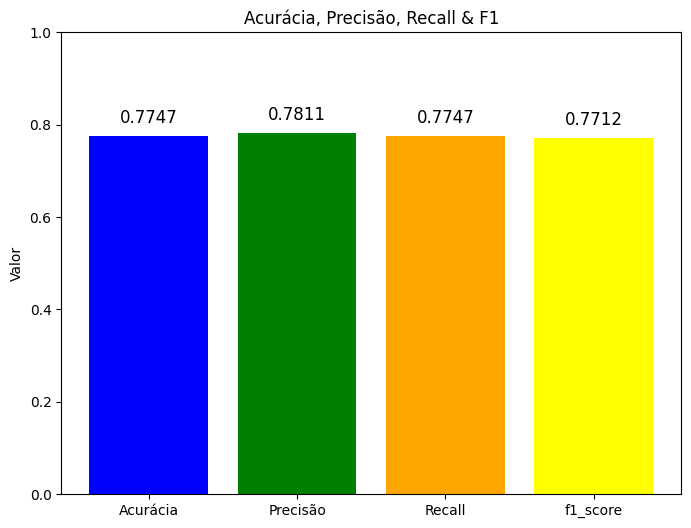

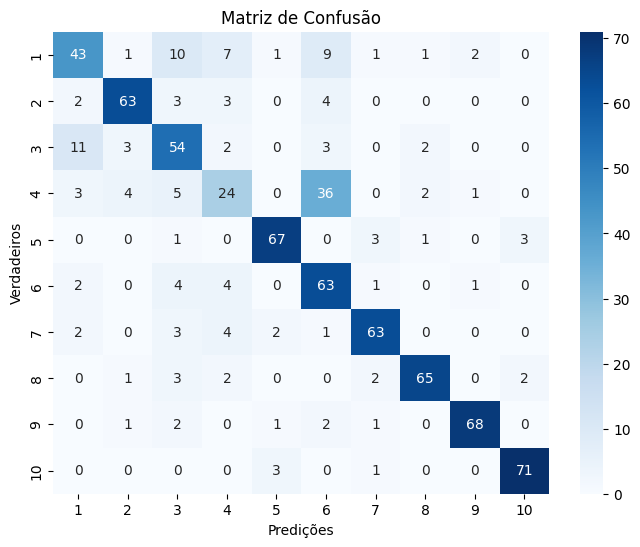

Acurácia: 0.7747
Precision: 0.7811
Recall: 0.7747
F1 Score: 0.7712
Confusion Matrix:
[[43  1 10  7  1  9  1  1  2  0]
 [ 2 63  3  3  0  4  0  0  0  0]
 [11  3 54  2  0  3  0  2  0  0]
 [ 3  4  5 24  0 36  0  2  1  0]
 [ 0  0  1  0 67  0  3  1  0  3]
 [ 2  0  4  4  0 63  1  0  1  0]
 [ 2  0  3  4  2  1 63  0  0  0]
 [ 0  1  3  2  0  0  2 65  0  2]
 [ 0  1  2  0  1  2  1  0 68  0]
 [ 0  0  0  0  3  0  1  0  0 71]]


In [7]:
%matplotlib inline
plotar_metricas(y_true, y_pred)